In [1]:
import os
import random

import numpy as np
import torch
from peft import LoraConfig, TaskType, get_peft_model
from torch import nn


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


class ModelForSourceCodeEmbedding(nn.Module):
    def __init__(self, model_name, normalize=True):
        super(ModelForSourceCodeEmbedding, self).__init__()
        self.model = AutoModel.from_pretrained(model_name, device_map="cuda:0", trust_remote_code=True)
        self.normalize = normalize

    def forward(self, **kwargs):
        model_output = self.model(**kwargs)
        
        embeddings = model_output.last_hidden_state[:, 0]
        if self.normalize:
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        return embeddings

    def __getattr__(self, name: str):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.model, name)

In [2]:
from transformers import AutoModel, AutoTokenizer


model_name = "Salesforce/SFR-Embedding-Code-400M_R"
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="cuda:0")
model = ModelForSourceCodeEmbedding(model_name)

model

ModelForSourceCodeEmbedding(
  (model): NewModel(
    (embeddings): NewEmbeddings(
      (word_embeddings): Embedding(30528, 1024, padding_idx=0)
      (rotary_emb): NTKScalingRotaryEmbedding()
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): NewEncoder(
      (layer): ModuleList(
        (0-23): 24 x NewLayer(
          (attention): NewSdpaAttention(
            (qkv_proj): Linear(in_features=1024, out_features=3072, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): NewGatedMLP(
            (up_gate_proj): Linear(in_features=1024, out_features=8192, bias=False)
            (down_proj): Linear(in_features=4096, out_features=1024, bias=True)
            (act_fn): GELUActivation()
            (hidden_dropout): Dropout(p=0.1, inpl

In [3]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION,
    target_modules=["qkv_proj"],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 786,432 || all params: 434,925,568 || trainable%: 0.1808199052579038


In [4]:
torch.cuda.empty_cache()

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device);

In [6]:
def get_cosing(q1_embs, q2_embs):
    return torch.sum(q1_embs * q2_embs, axis=1)

def get_loss(cosine_score, labels):
    return torch.mean(torch.square(labels * (1 - cosine_score) + torch.clamp((1 - labels) * cosine_score, min=0.0)))

def threshold(x):
    return 1 if x > 0.5 else 0

In [7]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
from tqdm import tqdm


train_cases = ["case-01", "case-02", "case-03", "case-04", "case-05"]
test_cases = ["case-06", "case-07"]

all_cases = ["case-01", "case-02", "case-03", "case-04", "case-05", "case-06", "case-07"]


def get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths):
    data = []

    for non_plagiarized_file_path in non_plagiarized_files_paths:
        data.append([original_file_path, non_plagiarized_file_path, 0])

    for plagiarized_file_path in plagiarized_files_paths:
        data.append([original_file_path, plagiarized_file_path, 1])

    df = pd.DataFrame(data, columns=["original_code_file", "secondary_code_file", "label"])
    
    return df

def get_paths(case, mode):
    original_file_path = os.path.join("plagiarism_dataset", case, "original", os.listdir(
        f"plagiarism_dataset/{case}/original")[0])

    # get all other cases' files:
    non_plagiarized_files_paths_all = []
    if mode == "train":
        for every_other_case in train_cases:
            if every_other_case != case:
                non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join("plagiarism_dataset", every_other_case)) for f in filenames if os.path.splitext(f)[1] == '.java']
                non_plagiarized_files_paths_all += non_plagiarized_files_paths
    else:
        for every_other_case in all_cases:
            if every_other_case != case:
                non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join("plagiarism_dataset", every_other_case)) for f in filenames if os.path.splitext(f)[1] == '.java']
                non_plagiarized_files_paths_all += non_plagiarized_files_paths

    # add your own case non-plagiarised files:
    non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join(
        "plagiarism_dataset", case, "non-plagiarized")) for f in filenames if os.path.splitext(f)[1] == '.java']
    non_plagiarized_files_paths_all += non_plagiarized_files_paths

    plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join(
        "plagiarism_dataset", case, "plagiarized")) for f in filenames if os.path.splitext(f)[1] == '.java']

    return original_file_path, non_plagiarized_files_paths_all, plagiarized_files_paths

In [8]:
original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths("case-01", "train")
print("Original")
print(original_file_path)
print("Non-plagiarized")
print(non_plagiarized_files_paths)
print("Plagiarized")
print(plagiarized_files_paths)

Original
plagiarism_dataset\case-01\original\T1.java
Non-plagiarized
['plagiarism_dataset\\case-02\\non-plagiarized\\01\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\02\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\03\\Nomor2_2451041557A22145B3701B0184109CAB013.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\04\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\05\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\06\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\07\\Main.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\08\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\09\\t02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\10\\Main.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\11\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\12\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\13\\No2.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\14\\Soal2.java', 'plagiarism_dataset

In [9]:
original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths("case-06", "test")
print("Original")
print(original_file_path)
print("Non-plagiarized")
print(non_plagiarized_files_paths)
print("Plagiarized")
print(plagiarized_files_paths)

Original
plagiarism_dataset\case-06\original\T6.java
Non-plagiarized
['plagiarism_dataset\\case-01\\non-plagiarized\\01\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\02\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\03\\Nomor1_2451041557A22145B3701B0184109CAB013.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\04\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\05\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\06\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\07\\Main.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\08\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\09\\t01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\10\\Main.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\11\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\12\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\13\\No1.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\14\\Soal1.java', 'plagiarism_dataset

In [10]:
# train-test cycle:
EPOCHS = 50

epochs_losses_train = []
epochs_accuracies_train = []

epochs_losses_test = []
epochs_accuracies_test = []

for epoch in range(EPOCHS):
    train_total_loss = 0
    train_correct = 0
    
    test_total_loss = 0
    test_correct = 0
    
    # train:
    for case in train_cases:
        original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths(case, "train")
        train_df = get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths)
        train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X_train, y_train = train_df[["original_code_file", "secondary_code_file"]], train_df["label"]
    
        ros = RandomOverSampler(random_state=42)
        X_train, y_train = ros.fit_resample(X_train, y_train)
        
        X_train = X_train.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
    
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
        loss = nn.CrossEntropyLoss()
        
        total_loss = 0
        correct = 0
        
        model.train()
        bar = tqdm(range(len(X_train)))
        for i in range(len(X_train)):
            original_code = open(X_train["original_code_file"][i], "r").read()
            secondary_code = open(X_train["secondary_code_file"][i], "r").read()
            
            q1 = tokenizer(original_code, max_length=8192, padding=True, truncation=True, return_tensors='pt')
            q2 = tokenizer(secondary_code, max_length=8192, padding=True, truncation=True, return_tensors='pt')
            
            q1 = {k: v.to(device) for k, v in q1.items()} # move to GPU
            q2 = {k: v.to(device) for k, v in q2.items()} # move to GPU
            
            label = torch.tensor([y_train[i]])
            label = label.to(device)
            
            optimizer.zero_grad()
            q1 = model(**q1)
            q2 = model(**q2)
            loss_value = get_loss(get_cosing(q1, q2).to(device), label)
            total_loss += loss_value.item()
            loss_value.backward()
            optimizer.step()
        
            prediction = threshold(get_cosing(q1, q2).item())
            if prediction == label:
                correct += 1
            bar.update(1)
        
        train_total_loss += total_loss / len(X_train)
        train_correct += correct / len(X_train)

    # test:
    for case in test_cases:
        original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths(case, "test")
        test_df = get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths)
        test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X_test, y_test = test_df[["original_code_file", "secondary_code_file"]], test_df["label"]
    
        total_loss = 0
        correct = 0
        
        model.eval()
        bar = tqdm(range(len(X_test)))
        for i in range(len(X_test)):
            original_code = open(X_test["original_code_file"][i], "r").read()
            secondary_code = open(X_test["secondary_code_file"][i], "r").read()

            q1 = tokenizer(original_code, max_length=8192, padding=True, truncation=True, return_tensors='pt')
            q2 = tokenizer(secondary_code, max_length=8192, padding=True, truncation=True, return_tensors='pt')
            
            q1 = {k: v.to(device) for k, v in q1.items()}
            q2 = {k: v.to(device) for k, v in q2.items()}
            
            label = torch.tensor([y_test[i]])
            label = label.to(device)
            
            q1 = model(**q1)
            q2 = model(**q2)
            loss_value = get_loss(get_cosing(q1, q2).to(device), label)
            total_loss += loss_value.item()
            
            prediction = threshold(get_cosing(q1, q2).item())
            if prediction == label:
                correct += 1
            bar.update(1)
        
        test_total_loss += total_loss / len(X_test)
        test_correct += correct / len(X_test)
    
    epochs_losses_train.append(train_total_loss / 5)
    print(f"Epoch: {epoch}, Loss train: {train_total_loss / 5}")
    epochs_accuracies_train.append(train_correct / 5)
    print(f"Epoch: {epoch}, Accuracy train: {train_correct / 5}")
    
    epochs_losses_test.append(test_total_loss / 2)
    print(f"Epoch: {epoch}, Loss test: {test_total_loss / 2}")
    epochs_accuracies_test.append(test_correct / 2)
    print(f"Epoch: {epoch}, Accuracy test: {test_correct / 2}")

    torch.save(model.state_dict(), f"models_sfr_embedding_original/{epoch + 1}_emb_model.pth")

  0%|          | 0/584 [00:00<?, ?it/s]C:\Users\bred7\.cache\huggingface\modules\transformers_modules\Alibaba-NLP\new-impl\40ced75c3017eb27626c9d4ea981bde21a2662f4\modeling.py:579: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
100%|██████████| 584/584 [02:52<00:00,  3.38it/s]

100%|██████████| 560/560 [04:52<00:00,  1.91it/s]

100%|██████████| 558/558 [03:08<00:00,  2.96it/s]

100%|██████████| 466/466 [02:20<00:00,  3.31it/s]

Epoch: 0, Loss train: 0.05220766725850338
Epoch: 0, Accuracy train: 0.9335935966837917
Epoch: 0, Loss test: 0.08492222822645215
Epoch: 0, Accuracy test: 0.8937768240343348



100%|██████████| 466/466 [02:24<00:00,  3.22it/s]

100%|██████████| 556/556 [03:52<00:00,  2.39it/s]

100%|██████████| 556/556 [03:13<00:00,  2.88it/s]

100%|██████████| 466/466 [01:51<00:00,  4.18it/s]

100%|██████████| 466/466 [02:22<00:00,  2.90it/s]

Epoch: 1, Loss train: 0.02325193172317326
Epoch: 1, Accuracy train: 0.9747731408964111
Epoch: 1, Loss test: 0.08541230461439434
Epoch: 1, Accuracy test: 0.8937768240343348


100%|██████████| 584/584 [02:52<00:00,  3.38it/s]

100%|██████████| 560/560 [04:52<00:00,  1.92it/s]

100%|██████████| 558/558 [03:08<00:00,  2.97it/s]

100%|██████████| 466/466 [02:21<00:00,  2.91it/s]

...


100%|██████████| 466/466 [02:28<00:00,  3.13it/s]

100%|██████████| 556/556 [03:51<00:00,  2.40it/s]

100%|██████████| 556/556 [03:12<00:00,  2.88it/s]

100%|██████████| 466/466 [01:51<00:00,  4.17it/s]

100%|██████████| 466/466 [02:22<00:00,  2.90it/s]

Epoch: 29, Loss train: 0.002429602270430253
Epoch: 29, Accuracy train: 0.9982289628180039
Epoch: 29, Loss test: 0.11246634784457614
Epoch: 29, Accuracy test: 0.8969957081545064


100%|██████████| 584/584 [02:52<00:00,  3.38it/s]

100%|██████████| 560/560 [04:53<00:00,  1.91it/s]

100%|██████████| 558/558 [03:08<00:00,  2.96it/s]

100%|██████████| 466/466 [02:21<00:00,  2.90it/s]

Epoch: 30, Loss train: 0.0018909211239557656
Epoch: 30, Accuracy train: 0.9989432485322898
Epoch: 30, Loss test: 0.12090841259032473
Epoch: 30, Accuracy test: 0.8991416309012875


RuntimeError: [enforce fail at inline_container.cc:595] . unexpected pos 276316288 vs 276316176

In [21]:
epochs_losses_test

[0.08492222822645215,
 0.08541230461439434,
 0.09516980701912245,
 0.08499480185702363,
 0.08132267213967895,
 0.0867375634502065,
 0.08512215599463918,
 0.08283546306569232,
 0.08650171417745152,
 0.09220965034492913,
 0.09501060830257854,
 0.07769474198918516,
 0.08585958334010294,
 0.09160710469277726,
 0.08024339151353517,
 0.08823108993155424,
 0.08247161450817253,
 0.09652021404307727,
 0.08247978277625709,
 0.08964765506215494,
 0.11222702311874296,
 0.10815965063418911,
 0.10703520493136523,
 0.11408292238362104,
 0.09448182188528383,
 0.11098323612889124,
 0.11821400870906812,
 0.13600014763077095,
 0.11750277227652858,
 0.11246634784457614,
 0.12090841259032473]

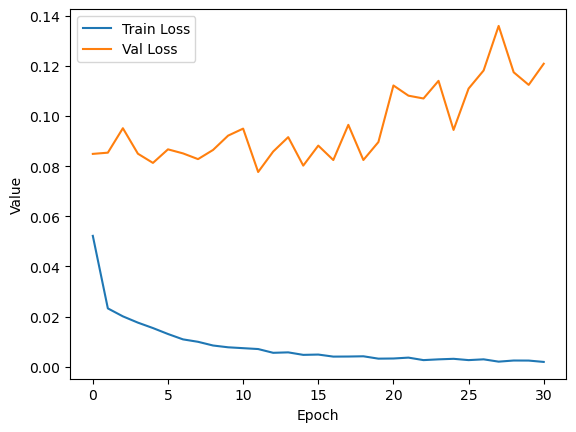

In [22]:
import matplotlib.pyplot as plt

EPOCHS = 30

plt.plot(epochs_losses_train, label="Train Loss")
plt.plot(epochs_losses_test, label="Val Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Value")

plt.show()

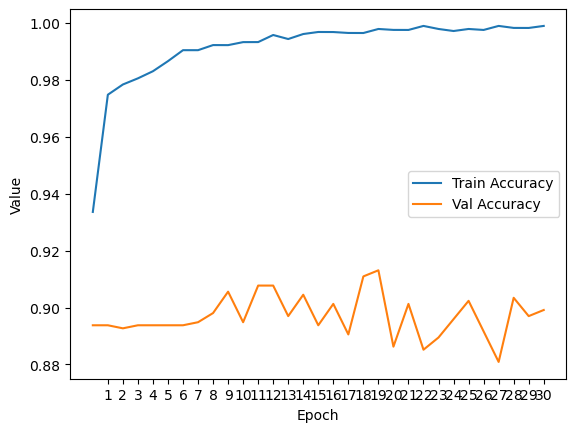

In [23]:
plt.plot(epochs_accuracies_train, label="Train Accuracy")
plt.plot(epochs_accuracies_test, label="Val Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

In [24]:
# torch.save(model, "models_codebert/code_embedding_model.pth")

In [25]:
# model = torch.load("code_embedding_model.pth")
# model.eval()

In [26]:
epochs_losses_test, len(epochs_losses_test)

([0.08492222822645215,
  0.08541230461439434,
  0.09516980701912245,
  0.08499480185702363,
  0.08132267213967895,
  0.0867375634502065,
  0.08512215599463918,
  0.08283546306569232,
  0.08650171417745152,
  0.09220965034492913,
  0.09501060830257854,
  0.07769474198918516,
  0.08585958334010294,
  0.09160710469277726,
  0.08024339151353517,
  0.08823108993155424,
  0.08247161450817253,
  0.09652021404307727,
  0.08247978277625709,
  0.08964765506215494,
  0.11222702311874296,
  0.10815965063418911,
  0.10703520493136523,
  0.11408292238362104,
  0.09448182188528383,
  0.11098323612889124,
  0.11821400870906812,
  0.13600014763077095,
  0.11750277227652858,
  0.11246634784457614,
  0.12090841259032473],
 31)

In [27]:
epochs_accuracies_test, len(epochs_accuracies_test)

([0.8937768240343348,
  0.8937768240343348,
  0.8927038626609443,
  0.8937768240343348,
  0.8937768240343348,
  0.8937768240343348,
  0.8937768240343348,
  0.8948497854077253,
  0.898068669527897,
  0.9055793991416309,
  0.8948497854077253,
  0.907725321888412,
  0.907725321888412,
  0.8969957081545064,
  0.9045064377682404,
  0.8937768240343347,
  0.9012875536480687,
  0.890557939914163,
  0.9109442060085837,
  0.9130901287553648,
  0.8862660944206009,
  0.9012875536480687,
  0.8851931330472103,
  0.8894849785407726,
  0.8959227467811158,
  0.9023605150214592,
  0.8916309012875536,
  0.880901287553648,
  0.9034334763948497,
  0.8969957081545064,
  0.8991416309012875],
 31)

In [28]:
print(f"Max accuracy: {max(epochs_accuracies_test)} at epoch {epochs_accuracies_test.index(max(epochs_accuracies_test)) + 1}")
print(f"Min loss: {min(epochs_losses_test)} at epoch {epochs_losses_test.index(min(epochs_losses_test)) + 1}")

Max accuracy: 0.9130901287553648 at epoch 20
Min loss: 0.07769474198918516 at epoch 12
